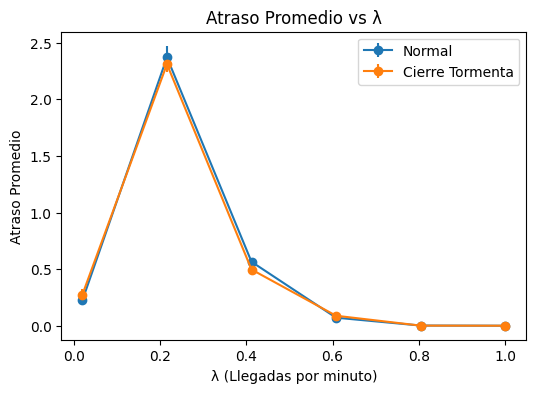

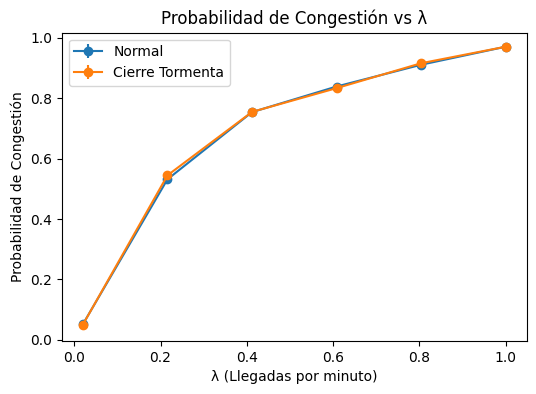

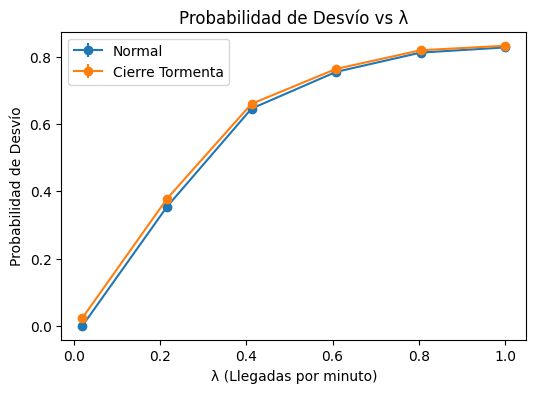

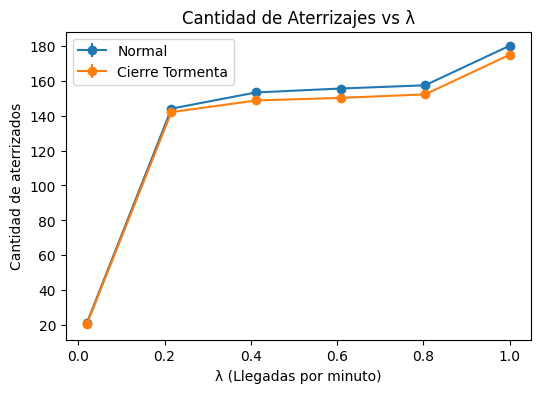

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from main import Simulador, SimuladorTormenta

def experimento_comparativo(lams, simulador_cls, reps=20, minutos=18*60, seed=42):
    rng = np.random.default_rng(seed)
    registros = []

    for lam in lams:
        atrasos, desv, prob_congest = [], [], []

        for _ in range(reps):
            if simulador_cls.__name__ == "SimuladorTormenta":
                # Crear simulador normal
                sim = simulador_cls(seed=rng.integers(1e9))
                # Setear atributos de tormenta manualmente
                sim.cierre_inicio = rng.integers(60, minutos-30)
                sim.cierre_duracion = 30
            else:
                sim = simulador_cls(seed=rng.integers(1e9))

            sim.simular_dia(lam, minutos)

            # Calcular métricas
            atrasos.append(np.mean([a.retraso for a in sim.finalizados]))
            desv.append(sum(a.estado=="DESVIADO" for a in sim.finalizados) / len(sim.finalizados))

            congestionados = sum(a.congestionado for a in sim.finalizados)
            total_aviones = len(sim.finalizados)
            prob_congest.append(congestionados / total_aviones if total_aviones > 0 else 0)

        registros.append({
            "lambda": lam,
            "modelo": simulador_cls.__name__,
            "atraso_prom": np.mean(atrasos),
            "ic_atraso": 1.96*np.std(atrasos, ddof=1)/np.sqrt(reps),
            "pct_desv": np.mean(desv),
            "ic_desv": 1.96*np.std(desv, ddof=1)/np.sqrt(reps),
            "prob_congest": np.mean(prob_congest),
            "ic_prob_congest": 1.96*np.std(prob_congest, ddof=1)/np.sqrt(reps)
        })

    return pd.DataFrame(registros)



lams = np.linspace(0.02, 1, 6)
df_normal = experimento_comparativo(lams, Simulador, reps=20)
df_tormenta = experimento_comparativo(lams, SimuladorTormenta, reps=20)





def experimento_comparativo(lams, simulador_cls, reps=20, minutos=18*60):
    rng = np.random.default_rng(50)
    resultados = []

    for lam in lams:
        atrasos = []
        congestiones = []
        desviados_rel = []
        aterrizados_abs = []
        desviados_abs = []

        for _ in range(reps):
            if simulador_cls == SimuladorTormenta:
                cierre_inicio = rng.integers(60, minutos-30)
                sim = simulador_cls(seed=rng.integers(1e9), cierre_inicio=cierre_inicio, cierre_duracion=30)
            else:
                sim = simulador_cls(seed=rng.integers(1e9))

            sim.simular_dia(lam, minutos)
            finalizados = sim.finalizados
            if not finalizados:
                continue

            atrasos.append(np.mean([a.retraso for a in finalizados]))
            congestiones.append(sum(a.congestionado for a in finalizados)/len(finalizados))

            # métricas de desviados y aterrizados
            n_desv = sum(a.estado == "DESVIADO" for a in finalizados)
            n_land = sum(a.estado == "ATERRIZADO" for a in finalizados)
            desviados_rel.append(n_desv / len(finalizados))
            aterrizados_abs.append(n_land)
            desviados_abs.append(n_desv)

        resultados.append({
            "lam": lam,
            "atraso_prom": np.mean(atrasos),
            "error_atraso": np.std(atrasos)/np.sqrt(len(atrasos)),
            "congestion_prob": np.mean(congestiones),
            "error_congestion": np.std(congestiones)/np.sqrt(len(congestiones)),
            "desvio_prob": np.mean(desviados_rel),
            "error_desviados": np.std(desviados_rel)/np.sqrt(len(desviados_rel)),
            "landed_mean": np.mean(aterrizados_abs),
            "landed_err": np.std(aterrizados_abs)/np.sqrt(len(aterrizados_abs)),
            "desv_mean": np.mean(desviados_abs),
            "desv_err": np.std(desviados_abs)/np.sqrt(len(desviados_abs)),
        })

    return pd.DataFrame(resultados)



lams = np.linspace(0.02, 1, 6)
df_normal = experimento_comparativo(lams, Simulador, reps=20)
df_tormenta = experimento_comparativo(lams, SimuladorTormenta, reps=20)



# 1) Atraso promedio
plt.figure(figsize=(6,4))
plt.errorbar(df_normal['lam'], df_normal['atraso_prom'], yerr=df_normal['error_atraso'], fmt='-o', label='Normal')
plt.errorbar(df_tormenta['lam'], df_tormenta['atraso_prom'], yerr=df_tormenta['error_atraso'], fmt='-o', label='Cierre Tormenta')
plt.xlabel('λ (Llegadas por minuto)')
plt.ylabel('Atraso Promedio')
plt.title('Atraso Promedio vs λ')
plt.legend()
plt.show()

# 2) Probabilidad de congestión
plt.figure(figsize=(6,4))
plt.errorbar(df_normal['lam'], df_normal['congestion_prob'], yerr=df_normal['error_congestion'], fmt='-o', label='Normal')
plt.errorbar(df_tormenta['lam'], df_tormenta['congestion_prob'], yerr=df_tormenta['error_congestion'], fmt='-o', label='Cierre Tormenta')
plt.xlabel('λ (Llegadas por minuto)')
plt.ylabel('Probabilidad de Congestión')
plt.title('Probabilidad de Congestión vs λ')
plt.legend()
plt.show()

# 3) Probabilidad de desvío
plt.figure(figsize=(6,4))
plt.errorbar(df_normal['lam'], df_normal['desvio_prob'], yerr=df_normal['error_desviados'], fmt='-o', label='Normal')
plt.errorbar(df_tormenta['lam'], df_tormenta['desvio_prob'], yerr=df_tormenta['error_desviados'], fmt='-o', label='Cierre Tormenta')
plt.xlabel('λ (Llegadas por minuto)')
plt.ylabel('Probabilidad de Desvío')
plt.title('Probabilidad de Desvío vs λ')
plt.legend()
plt.show()

# 4) Cantidad de aterrizados
plt.figure(figsize=(6,4))
plt.errorbar(df_normal['lam'], df_normal['landed_mean'], yerr=df_normal['landed_err'], fmt='-o', label='Normal')
plt.errorbar(df_tormenta['lam'], df_tormenta['landed_mean'], yerr=df_tormenta['landed_err'], fmt='-o', label='Cierre Tormenta')
plt.xlabel('λ (Llegadas por minuto)')
plt.ylabel('Cantidad de aterrizados')
plt.title('Cantidad de Aterrizajes vs λ')
plt.legend()
plt.show()




In [15]:
import pandas as pd

def tabla_resumen(df, nombre):
    tabla = pd.DataFrame({
        "λ": df["lam"].round(2),

        # Atraso
        "Atraso (prom)": df["atraso_prom"].round(2),
        "Atraso (±err)": df["error_atraso"].round(2),
        "Atraso (±IC95)": [f"{m:.2f} ± {1.96*se:.2f}" for m, se in zip(df["atraso_prom"], df["error_atraso"])],

        # Congestión
        "Congestión (prom)": df["congestion_prob"].round(2),
        "Congestión (±err)": df["error_congestion"].round(2),
        "Congestión (±IC95)": [f"{m:.2f} ± {1.96*se:.2f}" for m, se in zip(df["congestion_prob"], df["error_congestion"])],

        # Desvíos
        "Prob. Desvío (prom)": df["desvio_prob"].round(2),
        "Desvíos (±err)": df["error_desviados"].round(2),
        "Desvíos (±IC95)": [f"{m:.2f} ± {1.96*se:.2f}" for m, se in zip(df["desvio_prob"], df["error_desviados"])],

        # Aterrizados
        "Aterrizados (prom)": df["landed_mean"].round(1),
        "Aterrizados (±err)": df["landed_err"].round(1),
        "Aterrizados (±IC95)": [f"{m:.1f} ± {1.96*se:.1f}" for m, se in zip(df["landed_mean"], df["landed_err"])],

        # Desviados
        "Desviados (prom)": df["desv_mean"].round(1),
        "Desviados (±err)": df["desv_err"].round(1),
        "Desviados (±IC95)": [f"{m:.1f} ± {1.96*se:.1f}" for m, se in zip(df["desv_mean"], df["desv_err"])],
    })
    tabla.insert(0, "Modelo", nombre)
    return tabla

# Crear tabla
tabla_tormenta = tabla_resumen(df_tormenta, "Cierre Tormenta")

# Guardar CSV
tabla_tormenta.to_csv("tabla_resultados.csv", index=False)

# Mostrar en notebook
from IPython.display import display
display(tabla_tormenta)





,Modelo,λ,Atraso (prom),Atraso (±err),Atraso (±IC95),Congestión (prom),Congestión (±err),Congestión (±IC95),Prob. Desvío (prom),Desvíos (±err),Desvíos (±IC95),Aterrizados (prom),Aterrizados (±err),Aterrizados (±IC95),Desviados (prom),Desviados (±err),Desviados (±IC95)
0,Cierre Tormenta,0.02%,0.28%,0.05%,0.28 ± 0.09,0.05%,0.01%,0.05 ± 0.01,0.02%,0.01%,0.02 ± 0.01,20.60%,0.90%,20.6 ± 1.7,0.50%,0.20%,0.5 ± 0.3
1,Cierre Tormenta,0.22%,2.31%,0.07%,2.31 ± 0.14,0.54%,0.01%,0.54 ± 0.01,0.38%,0.01%,0.38 ± 0.01,142.00%,0.70%,142.0 ± 1.4,86.60%,2.40%,86.7 ± 4.7
2,Cierre Tormenta,0.41%,0.50%,0.03%,0.50 ± 0.05,0.75%,0.00%,0.75 ± 0.01,0.66%,0.00%,0.66 ± 0.00,148.60%,0.70%,148.7 ± 1.3,289.20%,2.60%,289.1 ± 5.1
3,Cierre Tormenta,0.61%,0.09%,0.02%,0.09 ± 0.03,0.83%,0.00%,0.83 ± 0.00,0.76%,0.00%,0.76 ± 0.00,150.20%,0.90%,150.2 ± 1.8,486.40%,2.80%,486.4 ± 5.5
4,Cierre Tormenta,0.80%,0.00%,0.00%,0.00 ± 0.00,0.92%,0.00%,0.92 ± 0.00,0.82%,0.00%,0.82 ± 0.00,152.20%,0.50%,152.2 ± 1.1,691.80%,2.50%,691.9 ± 4.9
5,Cierre Tormenta,1.00%,0.00%,0.00%,0.00 ± 0.00,0.97%,0.00%,0.97 ± 0.00,0.83%,0.00%,0.83 ± 0.00,174.80%,0.10%,174.8 ± 0.2,872.20%,0.10%,872.2 ± 0.2
